# Objetivo

Analisar a jornada de implantação de clientes para identificar:
- gargalos operacionais;
- tempo médio de implantação;
- padrões de cancelamento;
- impacto do engajamento no sucesso do cliente.

In [27]:
!pip install faker

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from faker import Faker
from datetime import timedelta

In [ ]:
#GERANDO BANCO DE DADO FICTICIO

In [29]:
fake = Faker('pt_BR')

segmentos = ['Hotelaria', 'Turismo', 'E-commerce', 'Marketing']
planos = ['Básico', 'Intermediário', 'Premium']
analistas = ['Ana', 'Carlos', 'Julia']

dados = []

In [30]:
for i in range(1, 101):

    data_inicio = fake.date_between(start_date='-6M', end_date='today')

    welcome = data_inicio + timedelta(days=random.randint(1,5))

    anuncios = welcome + timedelta(days=random.randint(1,5))

    concluido = random.choice([True, True, True, False])

    if concluido:
        decolar = anuncios + timedelta(days=random.randint(5,15))
        resolvido = decolar + timedelta(days=random.randint(2,5))
        status_cliente = 'Concluído'
        tempo = (resolvido - data_inicio).days

    else:
        decolar = None
        resolvido = None
        status_cliente = random.choice(['Em andamento', 'Cancelado'])
        tempo = None

    dados.append({
        'cliente_id': i,
        'empresa': fake.company(),
        'segmento': random.choice(segmentos),
        'plano': random.choice(planos),
        'data_criacao': data_inicio,
        'data_welcome': welcome,
        'data_anuncios': anuncios,
        'data_decolar': decolar,
        'data_resolvido': resolvido,
        'status_cliente': status_cliente,
        'qtd_reunioes': random.randint(1,8),
        'cs_responsavel': random.choice(analistas),
        'prioridade': random.choice(['Baixa', 'Média', 'Alta']),
        'nps': random.randint(1,10),
        'tempo_total_dias': tempo
    })

In [31]:
df = pd.DataFrame(dados)

df.head()

,cliente_id,empresa,segmento,plano,data_criacao,data_welcome,data_anuncios,data_decolar,data_resolvido,status_cliente,qtd_reunioes,cs_responsavel,prioridade,nps,tempo_total_dias
0,1,Borges,Marketing,Intermediário,2026-02-03,2026-02-06,2026-02-11,2026-02-25,2026-03-02,Concluído,3,Carlos,Baixa,8,27.0
1,2,Alves Ltda.,Marketing,Intermediário,2026-02-11,2026-02-12,2026-02-16,2026-02-27,2026-03-03,Concluído,1,Ana,Média,7,20.0
2,3,Lopes,Turismo,Básico,2025-11-17,2025-11-18,2025-11-23,None,None,Em andamento,3,Carlos,Alta,7,NaN
3,4,Silveira,Turismo,Básico,2026-04-04,2026-04-06,2026-04-10,None,None,Em andamento,8,Ana,Baixa,10,NaN
4,5,Martins da Mata Ltda.,Hotelaria,Básico,2026-03-05,2026-03-06,2026-03-07,None,None,Cancelado,5,Carlos,Alta,6,NaN


In [32]:
df.to_csv('base_clientes.csv', index=False)

In [39]:
df['status_cliente'].value_counts()

#Quantidade de clientes por status

,count
status_cliente,
Concluído,78
Em andamento,12
Cancelado,10


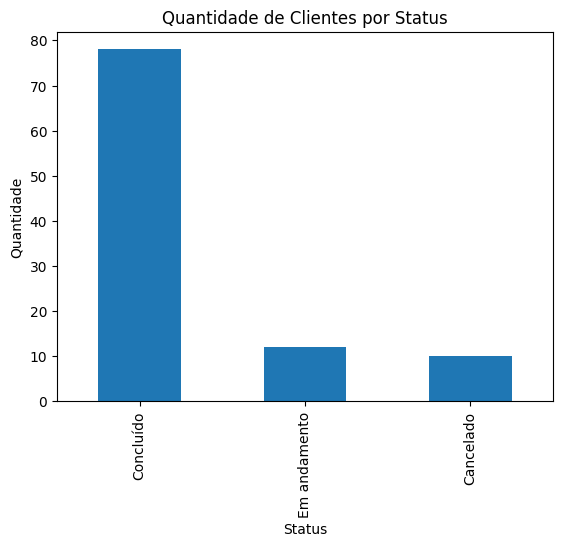

In [40]:
df['status_cliente'].value_counts().plot(kind='bar')

plt.title('Quantidade de Clientes por Status')
plt.xlabel('Status')
plt.ylabel('Quantidade')

plt.show()

In [41]:
#Tempo médio de implantação

df['tempo_total_dias'].mean()

#O tempo médio da jornada dos clientes concluídos foi de:

np.float64(19.141025641025642)

In [38]:
df.groupby('cs_responsavel')['nps'].mean()

#NPS médio por analista

,nps
cs_responsavel,
Ana,5.702703
Carlos,6.029412
Julia,5.344828


In [42]:
#Média de reuniões por status

df.groupby('status_cliente')['qtd_reunioes'].mean()

,qtd_reunioes
status_cliente,
Cancelado,3.800000
Concluído,4.294872
Em andamento,4.416667


In [43]:
df.to_csv('base_clientes.csv', index=False)

In [44]:
from google.colab import files

files.download('base_clientes.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>